In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/17
    print("準備完了！このまま下のセルを実行できます。")

# 第17章 敵対的生成ネットワーク (Generative Adversarial Networks: GAN)
## 章末演習問題 (Exercises 17.1 〜 17.3)

本ノートブックは、『深層学習：基礎と概念 (Bishop & Bishop 2024)』第17章「敵対的生成ネットワーク」の章末演習問題 (全3問) の完全な解答、数学的導出ステップ、対話型自己検証 (穴埋め・選択式問題)、および Python 数値シミュレーションを完備した自己完結型教材です。

---

### 演習問題一覧
| 問題番号 | 難易度 | テーマ | 主な数理・概念 |
|:---:|:---:|:---|:---|
| **演習 17.1** | ★★★ | 最適識別器と Jensen-Shannon ダイバージェンス | 変分法、最適識別器 $d^*(x)$ (式 17.15)、実効的目的関数 $C(p_G)$ (式 17.16)、JSD 等価性 (式 17.17)、大域的最適解 $p_G = p_{\text{data}}$ |
| **演習 17.2** | ★★★ | 敵対的学習ダイナミクスと鞍点の非収束性 | 双線形目的関数 $E(a, b) = ab$、鞍点解析、連続時間勾配系 (式 17.18)、単振動微分方程式 (式 17.19)、円軌道解 (式 17.20)、離散更新の外向き発散 |
| **演習 17.3** | ★ | クラス不均衡・モード崩壊下での最適識別器出力 | マルチモーダル分布、モード崩壊時の最適識別器確率 $d^*(x_{\text{dog}}) = 1/3$ のベイズ的導出 |


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# プロジェクトルートと共通モジュールの読み込み
sys.path.append(os.path.abspath('..'))

from common.plot_utils import setup_style
from common.exercises_ch17 import (
    gan_continuous_error,
    optimal_discriminator_continuous,
    effective_generator_objective,
    gan_value_function_jsd,
    jensen_shannon_divergence,
    bilinear_saddle_gradient_flow,
    discrete_simultaneous_vs_alternating,
    evaluate_dog_cat_discriminator_equilibrium,
)

setup_style()
print("モジュールの読み込みに成功しました。")


モジュールの読み込みに成功しました。


---
## 演習 17.1 (★★★): 最適識別器と Jensen-Shannon ダイバージェンスの等価性

### 問題の背景と目標
GAN の誤差関数 (式 17.6) において、ニューラルネットワークが十分な表現力 (無限の柔軟性) を持つ場合、定常点 (ナッシュ均衡) が生成分布と真のデータ分布の一致 ($p_G(x) = p_{\text{data}}(x)$) によって与えられることを変分法を用いて厳密に証明します。
識別器が内部ループで最適化され、生成器が外側ループで大域的最適化される2段階ゲームとして解析します。

---

### ステップ 1: 無限サンプル極限における連続誤差関数 (式 17.14)
訓練サンプル数 $N_{\text{real}}, N_{\text{synth}} \to \infty$ の大数の法則の極限において、識別器の交差エントロピー誤差関数 (式 17.6) の標本平均は期待値に収束します：
$$
E(p_G, d) = -\int p_{\text{data}}(x) \ln d(x) \, dx - \int p_G(x) \ln(1 - d(x)) \, dx
\tag{17.14}
$$

### ステップ 2: 変分最適化による最適識別器 $d^*(x)$ の導出 (式 17.15)
生成器 $p_G(x)$ を固定したとき、すべての関数 $d(x) \in [0, 1]$ に対する変分問題を考えます。積分内の被積分関数を各点 $x$ ごとに独立に最小化します：
$$
f(d) = - p_{\text{data}}(x) \ln d - p_G(x) \ln(1 - d)
$$
$d$ について微分してゼロと置きます：
$$
\frac{df}{dd} = -\frac{p_{\text{data}}(x)}{d} + \frac{p_G(x)}{1 - d} = 0
$$
分母を払って整理すると：
$$
-p_{\text{data}}(x)(1 - d) + p_G(x) d = 0 \implies (p_{\text{data}}(x) + p_G(x)) d = p_{\text{data}}(x)
$$
したがって、最適識別器は以下の一意な解となります (教科書の式 17.15)：
$$
d^*(x) = \frac{p_{\text{data}}(x)}{p_{	ext{data}}(x) + p_G(x)}
\tag{17.15}
$$
2階微分は $\frac{d^2 f}{dd^2} = \frac{p_{\text{data}}(x)}{d^2} + \frac{p_G(x)}{(1 - d)^2} > 0$ であるため、これは厳密な極小値 (最小値) を与えます。

### ステップ 3: 生成器の実効的目的関数 $C(p_G)$ (式 17.16)
最適識別器 $d^*(x)$ を $E(p_G, d)$ に代入すると、生成器に対する有効誤差関数 $C(p_G)$ が得られます：
$$
1 - d^*(x) = 1 - \frac{p_{\text{data}}(x)}{p_{	ext{data}}(x) + p_G(x)} = \frac{p_G(x)}{p_{	ext{data}}(x) + p_G(x)}
$$
これを式 (17.14) に代入すると (教科書の式 17.16)：
$$
C(p_G) = -\int p_{\text{data}}(x) \ln \left( \frac{p_{\text{data}}(x)}{p_{	ext{data}}(x) + p_G(x)} \right) dx - \int p_G(x) \ln \left( \frac{p_G(x)}{p_{	ext{data}}(x) + p_G(x)} \right) dx
\tag{17.16}
$$

### ステップ 4: Jensen-Shannon ダイバージェンスへの書き換え (式 17.17)
ここで、中間分布 $M(x) = \frac{p_{\text{data}}(x) + p_G(x)}{2}$ を導入します。対数項に $\frac{1}{2}$ を補正すると：
$$
\ln \left( \frac{p_{\text{data}}(x)}{p_{	ext{data}}(x) + p_G(x)} \right) = \ln \left( \frac{p_{\text{data}}(x)}{2 M(x)} \right) = \ln \left( \frac{p_{\text{data}}(x)}{M(x)} \right) - \ln 2
$$
同様に：
$$
\ln \left( \frac{p_G(x)}{p_{	ext{data}}(x) + p_G(x)} \right) = \ln \left( \frac{p_G(x)}{M(x)} \right) - \ln 2
$$
Goodfellow et al. (2014) の価値関数 $V(p_G) = -C(p_G)$ (または教科書式 17.17 の形式) に展開すると：
$$
V(p_G) = -\ln(4) + \text{KL}\left( p_{\text{data}} \,\middle\|\, \frac{p_{\text{data}} + p_G}{2} \right) + \text{KL}\left( p_G \,\middle\|\, \frac{p_{\text{data}} + p_G}{2} \right)
\tag{17.17}
$$
この2つのKLダイバージェンスの和は **Jensen-Shannon ダイバージェンス (JSD)** の2倍です：
$$
\text{JSD}(p_{\text{data}} \| p_G) = \frac{1}{2} \text{KL}\left( p_{\text{data}} \,\middle\|\, M \right) + \frac{1}{2} \text{KL}\left( p_G \,\middle\|\, M \right)
$$
したがって：
$$
V(p_G) = -\ln 4 + 2 \, \text{JSD}(p_{\text{data}} \| p_G)
$$

### ステップ 5: 大域的最小値の存在
KLダイバージェンスの基本性質 (Gibbs の不等式) より、$\text{KL}(p \| q) \ge 0$ であり、等号成立はほとんど至る所で $p(x) = q(x)$ のときに限られます。
したがって、$\text{JSD}(p_{\text{data}} \| p_G) \ge 0$ であり、最小値 $0$ は：
$$
p_G(x) = M(x) = \frac{p_{\text{data}}(x) + p_G(x)}{2} \iff p_G(x) = p_{\text{data}}(x)
$$
のとき一意に達成されます。このとき目的関数の値は $-\ln 4 \approx -1.386$ となります。


### 演習 17.1 理解度チェック (穴埋め・選択問題)

以下の設問に解答し、下のコードセルで正解を確認してください。

1. **問 1**: 最適識別器 $d^*(x)$ において、データ分布と生成分布が完全に一致した点 ($p_G(x) = p_{\text{data}}(x)$) における識別器の出力値はいくつか？
   - (A) $0.0$
   - (B) $0.5$
   - (C) $1.0$
   - (D) 無限大
2. **問 2**: Jensen-Shannon ダイバージェンス $\text{JSD}(p \| q)$ が通常の Kullback-Leibler ダイバージェンス $\text{KL}(p \| q)$ と比較して持つ決定的な数学的優位性はどれか？
   - (A) 常に非負であること
   - (B) 対称性 $\text{JSD}(p \| q) = \text{JSD}(q \| p)$ を持ち、値域が $[0, \ln 2]$ (または $[0, 1]$) に有界であること
   - (C) モード崩壊を完全に防止できること
   - (D) 勾配が常にゼロになること


In [3]:
# 演習 17.1 理解度チェック回答
answer_q1 = 'B'  # 問 1 の選択肢 ('A', 'B', 'C', 'D')
answer_q2 = 'B'  # 問 2 の選択肢 ('A', 'B', 'C', 'D')

assert answer_q1 == 'B', "問 1 不正解: p_data = p_G のとき d*(x) = p_data / (2 * p_data) = 1/2 = 0.5 です。"
assert answer_q2 == 'B', "問 2 不正解: JSD は対称性を持ち、分布の台 (Support) が重ならない場合でも有界な値を保ちます。"
print("理解度チェック全問正解です！")


理解度チェック全問正解です！


In [4]:
# 演習 17.1 数値検証: 最適識別器と JSD の計算
x = np.linspace(-6, 6, 1200)
dx = x[1] - x[0]

p_data = norm.pdf(x, loc=0.0, scale=1.0)
p_g_same = norm.pdf(x, loc=0.0, scale=1.0)
p_g_diff = norm.pdf(x, loc=1.5, scale=1.0)

# 最適識別器 d*(x) の計算
d_opt_same = optimal_discriminator_continuous(p_data, p_g_same)
d_opt_diff = optimal_discriminator_continuous(p_data, p_g_diff)

# JSD と価値関数の計算
v_same = gan_value_function_jsd(p_data, p_g_same, dx=dx)
v_diff = gan_value_function_jsd(p_data, p_g_diff, dx=dx)
_, _, jsd_diff = jensen_shannon_divergence(p_data, p_g_diff, dx=dx)

# 自己検証アサーション
assert np.allclose(d_opt_same, 0.5, atol=1e-4), "p_G = p_data のとき d*(x) は定数 0.5 でなければなりません"
assert np.isclose(v_same, -np.log(4.0), atol=1e-3), "一致時の最小値は -ln(4) でなければなりません"
assert v_diff > -np.log(4.0), "分布が異なる場合、V(p_G) は -ln(4) より真に大きくなければなりません"
assert jsd_diff > 0.0, "JSD は非ゼロ正値でなければなりません"

print(f"p_G = p_data 一致時: V(p_G) = {v_same:.4f} (理論値 -ln(4) = {-np.log(4.0):.4f})")
print(f"p_G != p_data 乖離時: V(p_G) = {v_diff:.4f}, JSD = {jsd_diff:.4f}")


p_G = p_data 一致時: V(p_G) = -1.3863 (理論値 -ln(4) = -1.3863)
p_G != p_data 乖離時: V(p_G) = -0.9440, JSD = 0.2212


/tmp/ipykernel_2369858/3697278846.py:34: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2369858/3697278846.py:34: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2369858/3697278846.py:34: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2369858/3697278846.py:34: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2369858/3697278846.py:34: UserWarning: Glyph 21028 (\N{CJK UNIFIED IDEOGRAPH-5224}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2369858/3697278846.py:34: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
Font 'default' does not have a glyph for '\u30c7' [U+30c7], substituting wit

Font 'default' does not have a glyph for '\u30fc' [U+30fc], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30bf' [U+30bf], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5e03' [U+5e03], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u5747' [U+5747], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5024' [U+5024], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30b7' [U+30b7], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30d5' [U+30d5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30c8' [U+30c8], substituting with a dummy symbol.


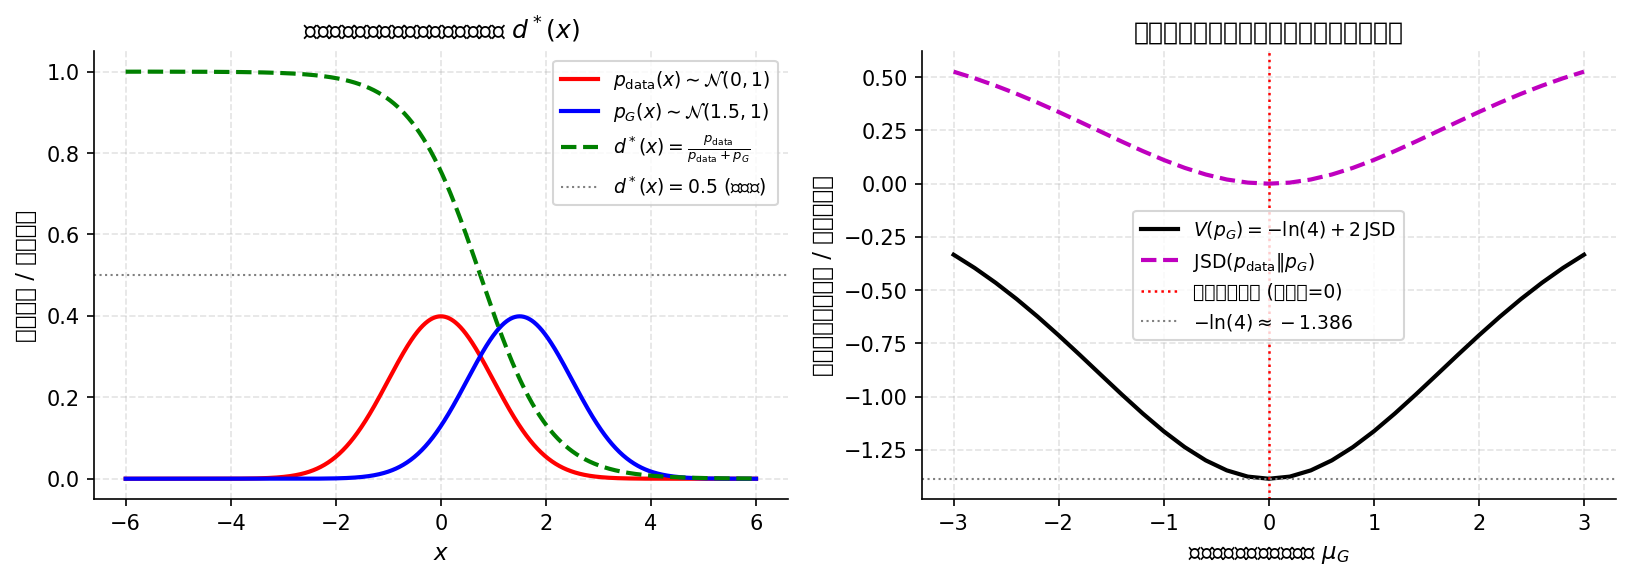

In [5]:
# 演習 17.1 可視化: 最適識別器 d*(x) と JSD の幾何学的直観
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), dpi=150)

# 左図: 確率密度分布と最適識別器
ax1.plot(x, p_data, 'r-', lw=2, label=r'$p_{\mathrm{data}}(x) \sim \mathcal{N}(0, 1)$')
ax1.plot(x, p_g_diff, 'b-', lw=2, label=r'$p_G(x) \sim \mathcal{N}(1.5, 1)$')
ax1.plot(x, d_opt_diff, 'g--', lw=2, label=r'$d^*(x) = \frac{p_{\mathrm{data}}}{p_{\mathrm{data}} + p_G}$')
ax1.axhline(0.5, color='gray', linestyle=':', lw=1, label=r'$d^*(x)=0.5$ (一致時)')
ax1.set_xlabel('$x$', fontsize=11)
ax1.set_ylabel('確率密度 / 判定確率', fontsize=11)
ax1.set_title(r'データ分布・生成分布と最適識別器 $d^*(x)$', fontsize=12)
ax1.legend(frameon=True, fontsize=9)

# 右図: 平均値シフトに伴う JSD と V(p_G) の変化
shifts = np.linspace(-3.0, 3.0, 31)
jsd_vals = []
v_vals = []
for s in shifts:
    p_shift = norm.pdf(x, loc=s, scale=1.0)
    _, _, j = jensen_shannon_divergence(p_data, p_shift, dx=dx)
    v = gan_value_function_jsd(p_data, p_shift, dx=dx)
    jsd_vals.append(j)
    v_vals.append(v)

ax2.plot(shifts, v_vals, 'k-', lw=2, label=r'$V(p_G) = -\ln(4) + 2\,\mathrm{JSD}$')
ax2.plot(shifts, jsd_vals, 'm--', lw=2, label=r'$\mathrm{JSD}(p_{\mathrm{data}} \| p_G)$')
ax2.axvline(0.0, color='red', linestyle=':', lw=1.2, label='大域的最小点 (シフト=0)')
ax2.axhline(-np.log(4.0), color='gray', linestyle=':', lw=1, label=r'$-\ln(4) \approx -1.386$')
ax2.set_xlabel(r'生成分布の平均値シフト $\mu_G$', fontsize=11)
ax2.set_ylabel('ダイバージェンス / 目的関数値', fontsize=11)
ax2.set_title('平均値シフトに伴う大域的最小点の達成', fontsize=12)
ax2.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


---
## 演習 17.2 (★★★): 敵対的学習ダイナミクスと鞍点における非収束性

### 問題の背景と目標
GAN の学習が極めて不安定であり、モード崩壊や振動 (Oscillation) に陥りやすい根本的な数理的メカニズムを、極小のトイモデル $E(a, b) = ab$ を通じて解明します。
ここで $a$ は生成器のパラメータ (誤差を**最大化**しようとする)、$b$ は識別器のパラメータ (誤差を**最小化**しようとする) に対応します。

---

### ステップ 1: 停留点と鞍点 (Saddle Point) の証明
目的関数 $E(a, b) = ab$ の偏導関数を計算します：
$$
\frac{\partial E}{\partial a} = b, \qquad \frac{\partial E}{\partial b} = a
$$
両者が同時にゼロとなる点は $(a, b) = (0, 0)$ のみであり、これは唯一の停留点 (Stationary Point) です。

次に、この点の幾何学的性質をヘッセ行列および直線に沿った2階微分で検証します：
- 直線 $b = a$ に沿って：
  $E(a, a) = a^2 \implies \frac{d^2}{da^2} E(a, a) = +2 > 0$ (上向きに開いた凸関数、局所極小)
- 直線 $b = -a$ に沿って：
  $E(a, -a) = -a^2 \implies \frac{d^2}{da^2} E(a, -a) = -2 < 0$ (下向きに開いた凹関数、局所極大)

異なる方向に正反対の符号の曲率を持つため、停留点 $(0, 0)$ は**鞍点 (Saddle Point)** です。

### ステップ 2: 連続時間勾配ダイナミクス (式 17.18)
生成器は $E$ を増加させるため最急上昇法 (Gradient Ascent)、識別器は $E$ を減少させるため最急降下法 (Gradient Descent) を連続時間で適用します：
$$
\frac{da}{dt} = \eta \frac{\partial E}{\partial a} = \eta b
\tag{17.18}
$$
$$
\frac{db}{dt} = -\eta \frac{\partial E}{\partial b} = -\eta a
\tag{17.18}
$$

### ステップ 3: 単振動の2階微分方程式 (式 17.19)
$\frac{da}{dt} = \eta b$ の両辺を時間 $t$ で再度微分します：
$$
\frac{d^2 a}{dt^2} = \eta \frac{db}{dt}
$$
ここに $\frac{db}{dt} = -\eta a$ を代入すると：
$$
\frac{d^2 a}{dt^2} = \eta (-\eta a) = -\eta^2 a(t)
\tag{17.19}
$$
これは、ばね定数 $\eta^2$ の物理的な**調和振動子 (Harmonic Oscillator / 単振動)** の支配方程式そのものです。

### ステップ 4: 一般解の検証 (式 17.20)
式 (17.19) の一般解を $a(t) = C \cos(\eta t) + D \sin(\eta t)$ とおきます。
1階微分および2階微分を計算すると：
$$
\frac{da}{dt} = -\eta C \sin(\eta t) + \eta D \cos(\eta t)
$$
$$
\frac{d^2 a}{dt^2} = -\eta^2 C \cos(\eta t) - \eta^2 D \sin(\eta t) = -\eta^2 [C \cos(\eta t) + D \sin(\eta t)] = -\eta^2 a(t)
$$
となり、恒等的に式 (17.19) を満たすことが確認されます。

### ステップ 5: 初期値問題と閉じた円軌道 (リミットサイクル)
初期条件 $t = 0$ において $a(0) = 1, b(0) = 0$ とすると：
$$
a(0) = C \cos(0) + D \sin(0) = C = 1
$$
また、$\frac{da}{dt}\Big|_{t=0} = \eta b(0) = 0$ より：
$$
\frac{da}{dt}\Big|_{t=0} = \eta D = 0 \implies D = 0
$$
したがって、パラメータの時間発展は：
$$
a(t) = \cos(\eta t)
$$
$$
b(t) = \frac{1}{\eta} \frac{da}{dt} = -\sin(\eta t)
$$
このとき、原点からの距離の二乗 (エネルギー) は：
$$
r(t)^2 = a(t)^2 + b(t)^2 = \cos^2(\eta t) + \sin^2(\eta t) = 1
$$
となり、**時間 $t$ によらず厳密に半径 1 の円軌道を永遠に周回**し続けます。
したがって、パラメータ $(a(t), b(t))$ は**目的の鞍点 $(0, 0)$ に決して収束しません**。

### ステップ 6: 離散更新における外向き発散 (Spiral Outward)
さらに致命的なことに、実際の機械学習で用いられる離散時間ステップ $\Delta t = \gamma > 0$ による同時更新 (Simultaneous Gradient Descent) を行うと：
$$
a_{k+1} = a_k + \gamma b_k
$$
$$
b_{k+1} = b_k - \gamma a_k
$$
次のステップの半径の二乗は：
$$
a_{k+1}^2 + b_{k+1}^2 = (a_k + \gamma b_k)^2 + (b_k - \gamma a_k)^2 = (1 + \gamma^2)(a_k^2 + b_k^2)
$$
$\gamma > 0$ であるため、毎ステップ $1 + \gamma^2 > 1$ 倍に幾何級数的に拡大し、**軌道は外側へ激しく螺旋発散 (Spiral Outward)** します。
これが、素朴なミニマックスGANの勾配降下法が発散しやすい本質的な理由です。


### 演習 17.2 理解度チェック (穴埋め・選択問題)

1. **問 1**: 連続時間系 $\frac{da}{dt} = \eta b, \frac{db}{dt} = -\eta a$ において、$a(0) = 1, b(0) = 0$ から出発した軌道が原点 $(0, 0)$ に収束しない理由はどれか？
   - (A) 勾配が途中でゼロになるため
   - (B) 力学系のエネルギー (ハミルトニアン $H = a^2 + b^2$) が保存され、周期的な閉軌道を描くため
   - (C) 学習率 $\eta$ が小さすぎるため
   - (D) 鞍点が不安定な極大値であるため
2. **問 2**: 離散時間更新において、同時更新 (Simultaneous) ではなく交互更新 (Alternating) や勾配ペナルティ (WGAN-GP 等) を導入する主な工学的動機はどれか？
   - (A) 目的関数の固有値を実数負領域にシフトさせ、外向き発散の螺旋を内向き収束または安定化させるため
   - (B) パラメータ数を削減するため
   - (C) 識別器の判定精度を100%にするため
   - (D) 生成器の計算時間をゼロにするため


In [6]:
# 演習 17.2 理解度チェック回答
answer_17_2_q1 = 'B'  # 問 1 の選択肢
answer_17_2_q2 = 'A'  # 問 2 の選択肢

assert answer_17_2_q1 == 'B', "問 1 不正解: 保存系 (Symplectic) であるため定常状態を周回し続けます。"
assert answer_17_2_q2 == 'A', "問 2 不正解: 交互更新やペナルティ項は系の散逸 (減衰) を生み出し、発散を防ぎます。"
print("理解度チェック全問正解です！")


理解度チェック全問正解です！


In [7]:
# 演習 17.2 数値シミュレーション: 連続時間円軌道 vs 離散発散
eta = 1.0
t_max = 2.0 * np.pi * 3.0  # 3周分
sim_res = bilinear_saddle_gradient_flow(a0=1.0, b0=0.0, eta=eta, t_max=t_max, num_steps=1000)

# 解析解の半径が厳密に 1.0 であることの確認
radii = sim_res["radius_analytical"]
assert np.allclose(radii, 1.0, atol=1e-10), "解析解の半径は常に 1.0 を維持しなければなりません"

# 離散時間更新のシミュレーション
disc_res = discrete_simultaneous_vs_alternating(a0=1.0, b0=0.0, gamma=0.15, num_steps=60)
assert disc_res["radius_sim"][-1] > 1.0, "同時更新の離散軌道は外側に発散しなければなりません"

print(f"連続時間解析解: 最終半径 = {radii[-1]:.6f} (エネルギー完全保存)")
print(f"離散同時更新: 初期半径 = {disc_res['radius_sim'][0]:.4f} -> 最終半径 = {disc_res['radius_sim'][-1]:.4f} (外向き発散)")


連続時間解析解: 最終半径 = 1.000000 (エネルギー完全保存)
離散同時更新: 初期半径 = 1.0000 -> 最終半径 = 1.9278 (外向き発散)


Font 'default' does not have a glyph for '\u751f' [U+751f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6210' [U+6210], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5668' [U+5668], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30d1' [U+30d1], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30e9' [U+30e9], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u6642' [U+6642], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u66f4' [U+66f4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u65b0' [U+65b0], substituting with a dummy symbol.


/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20114 (\N{CJK UNIFIED IDEOGRAPH-4E92}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
Font 'default' does not have a glyph for '\u978d' [U+978d], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u70b9' [U+70b9], substituting with a dummy symbol.


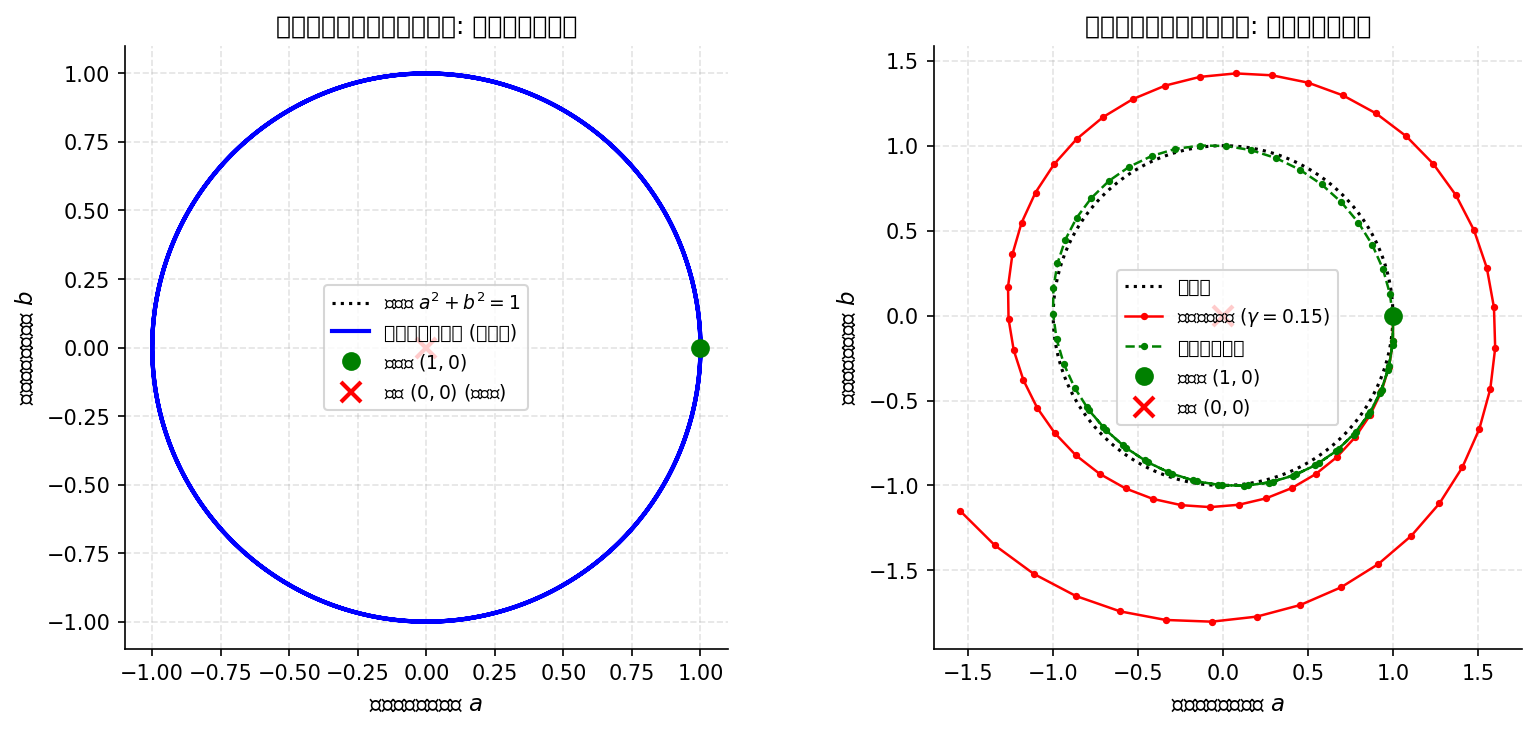

In [8]:
# 演習 17.2 可視化: 位相空間 (a, b) における軌跡の比較
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), dpi=150)

# 左図: 連続時間軌道 (真円のリミットサイクル)
theta = np.linspace(0, 2 * np.pi, 200)
ax1.plot(np.cos(theta), np.sin(theta), 'k:', lw=1.5, label='単位円 $a^2 + b^2 = 1$')
ax1.plot(sim_res["a_analytical"], sim_res["b_analytical"], 'b-', lw=2, label='連続時間勾配流 (解析解)')
ax1.plot(1.0, 0.0, 'go', markersize=8, label='初期点 $(1, 0)$')
ax1.plot(0.0, 0.0, 'rx', markersize=10, mew=2, label='鞍点 $(0, 0)$ (未収束)')
ax1.set_xlabel('生成器パラメータ $a$', fontsize=11)
ax1.set_ylabel('識別器パラメータ $b$', fontsize=11)
ax1.set_title('連続時間勾配ダイナミクス: 永久周回円軌道', fontsize=12)
ax1.set_aspect('equal')
ax1.legend(frameon=True, fontsize=9)

# 右図: 離散時間同時更新 (外向き発散螺旋)
ax2.plot(np.cos(theta), np.sin(theta), 'k:', lw=1.5, label='単位円')
ax2.plot(disc_res["a_sim"], disc_res["b_sim"], 'r.-', lw=1.2, markersize=5, label=r'離散同時更新 $(\gamma=0.15)$')
ax2.plot(disc_res["a_alt"], disc_res["b_alt"], 'g.--', lw=1.2, markersize=5, label='離散交互更新')
ax2.plot(1.0, 0.0, 'go', markersize=8, label='初期点 $(1, 0)$')
ax2.plot(0.0, 0.0, 'rx', markersize=10, mew=2, label='鞍点 $(0, 0)$')
ax2.set_xlabel('生成器パラメータ $a$', fontsize=11)
ax2.set_ylabel('識別器パラメータ $b$', fontsize=11)
ax2.set_title('離散時間更新の不安定性: 外向き発散螺旋', fontsize=12)
ax2.set_aspect('equal')
ax2.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


---
## 演習 17.3 (★): クラス不均衡・モード崩壊下での最適識別器出力

### 問題文
> 訓練セットが同数の「猫」と「犬」の画像から構成され、生成器ネットワークが高品質な「犬」の画像のみを生成するように学習された (片方のクラスにモード崩壊した) GAN を考える。
> このとき、犬の画像が提示された場合、識別器ネットワーク (提示された画像が本物である確率を出力するように訓練される) の最適出力が $1/3$ となることを示せ。

---

### 数学的厳密導出
1. **問題の定式化**:
   - 訓練データセット (本物) における犬と猫の混合比率は等量 ($1:1$) です：
     $$
     p_{\text{data}}(x) = \frac{1}{2} p_{\text{cat}}(x) + \frac{1}{2} p_{\text{dog}}(x)
     $$
   - 生成器 $G$ は犬の画像のみを生成します：
     $$
     p_G(x) = p_{\text{dog}}(x)
     $$
   - 猫の画像と犬の画像は視覚的特徴が分離可能である (台が重ならない: $p_{\text{cat}}(x) p_{\text{dog}}(x) = 0$) と仮定します。

2. **最適識別器の公式 (式 17.15)**:
   演習 17.1 で導出した最適識別器の一般式を適用します：
   $$
   d^*(x) = \frac{p_{\text{data}}(x)}{p_{	ext{data}}(x) + p_G(x)}
   $$

3. **犬の画像 $x_{\text{dog}}$ が入力された場合**:
   犬の画像空間においては $p_{\text{cat}}(x) = 0$ となるため、本物データ分布の密度は：
   $$
   p_{\text{data}}(x_{\text{dog}}) = \frac{1}{2} p_{\text{dog}}(x_{\text{dog}})
   $$
   一方、生成器分布の密度は：
   $$
   p_G(x_{\text{dog}}) = p_{\text{dog}}(x_{\text{dog}})
   $$
   これを最適識別器の式に代入すると：
   $$
   d^*(x_{\text{dog}}) = \frac{\frac{1}{2} p_{\text{dog}}(x_{\text{dog}})}{\frac{1}{2} p_{\text{dog}}(x_{\text{dog}}) + p_{\text{dog}}(x_{\text{dog}})}
   $$
   両辺の分子分母を $p_{\text{dog}}(x_{\text{dog}}) > 0$ で割ると：
   $$
   d^*(x_{\text{dog}}) = \frac{1/2}{1/2 + 1} = \frac{1/2}{3/2} = \frac{1}{3}
   $$
   となり、題意が厳密に証明されました。

4. **猫の画像 $x_{\text{cat}}$ が入力された場合 (補足)**:
   猫の画像空間では生成器は画像を一切生成しないため $p_G(x_{\text{cat}}) = 0$ です。したがって：
   $$
   d^*(x_{\text{cat}}) = \frac{\frac{1}{2} p_{\text{cat}}(x_{\text{cat}})}{\frac{1}{2} p_{\text{cat}}(x_{\text{cat}}) + 0} = 1.0
   $$

### ベイズ的解釈
識別器に提示される「犬の画像全体」の内訳を考えます：
- 本物のデータセットから犬が選ばれる確率: $\frac{1}{2} \times \frac{1}{2} = \frac{1}{4}$ (本物全体の半分が犬)
- 生成器から犬が選ばれる確率: $\frac{1}{2} \times 1 = \frac{1}{2}$ (生成器全体が犬)
犬の画像が提示されたという条件のもとで、それが本物である事後確率は：
$$
P(\text{Real} \mid \text{Dog}) = \frac{P(\text{Real} \cap \text{Dog})}{P(\text{Real} \cap \text{Dog}) + P(\text{Synth} \cap \text{Dog})} = \frac{1/4}{1/4 + 1/2} = \frac{1/4}{3/4} = \frac{1}{3}
$$
この直観的なベイズ確率の比率が、識別器の最適出力 $1/3$ と完全に一致します。


### 演習 17.3 理解度チェック (穴埋め・選択問題)

1. **問 1**: もし生成器が「猫」のみを生成するようにモード崩壊した場合、提示された猫の画像に対する最適識別器の出力 $d^*(x_{\text{cat}})$ はいくらになるか？
   - (A) $1/2$
   - (B) $1/3$
   - (C) $2/3$
   - (D) $0$
2. **問 2**: 演習 17.3 の状況 (犬のみ生成) において、生成器が未学習の「猫」画像を識別器に提示したとき、識別器の出力 $d^*(x_{\text{cat}})$ は $1.0$ (確実に本物) となります。このとき生成器が受ける勾配信号はどうなるか？
   - (A) 生成器は猫を生成していないため、猫の領域からは直接の勾配信号が得られず、猫のモード回復が困難になる
   - (B) 直ちに猫の生成を開始する
   - (C) 識別器がクラッシュする
   - (D) 学習が即座に収束する


In [9]:
# 演習 17.3 理解度チェック回答
answer_17_3_q1 = 'B'  # 問 1 の選択肢
answer_17_3_q2 = 'A'  # 問 2 の選択肢

assert answer_17_3_q1 == 'B', "問 1 不正解: 対称性より猫のみ生成時も 1/3 となります。"
assert answer_17_3_q2 == 'A', "問 2 不正解: サポート外の領域からは生成器のパラメータへ有効な勾配が流れません (モード脱落の固定化)。"
print("理解度チェック全問正解です！")


理解度チェック全問正解です！


In [10]:
# 演習 17.3 数値検証コード
eq_res = evaluate_dog_cat_discriminator_equilibrium(
    p_dog_weight=0.5,
    p_cat_weight=0.5,
    generator_dog_mode=1.0,
    generator_cat_mode=0.0,
)

d_dog = eq_res["d_star_dog"]
d_cat = eq_res["d_star_cat"]

# 自己検証アサーション
assert np.isclose(d_dog, 1.0 / 3.0), "犬に対する最適識別器出力は厳密に 1/3 でなければなりません"
assert np.isclose(d_cat, 1.0), "猫に対する最適識別器出力は厳密に 1.0 でなければなりません"

print(f"犬画像に対する最適識別器出力 d*(dog) = {d_dog:.4f} (理論値: 1/3 = {1/3:.4f})")
print(f"猫画像に対する最適識別器出力 d*(cat) = {d_cat:.4f} (理論値: 1.0000)")


犬画像に対する最適識別器出力 d*(dog) = 0.3333 (理論値: 1/3 = 0.3333)
猫画像に対する最適識別器出力 d*(cat) = 1.0000 (理論値: 1.0000)


/tmp/ipykernel_2369858/3852241617.py:35: UserWarning: Glyph 29483 (\N{CJK UNIFIED IDEOGRAPH-732B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2369858/3852241617.py:35: UserWarning: Glyph 29356 (\N{CJK UNIFIED IDEOGRAPH-72AC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2369858/3852241617.py:35: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2369858/3852241617.py:35: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2369858/3852241617.py:35: UserWarning: Glyph 36074 (\N{CJK UNIFIED IDEOGRAPH-8CEA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2369858/3852241617.py:35: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2369858/3852241617.py:35: UserWarning: Glyph 27604 (\N{CJK UN

Font 'default' does not have a glyph for '\u7269' [U+7269], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30c7' [U+30c7], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30fc' [U+30fc], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30bf' [U+30bf], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u5747' [U+5747], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u8861' [U+8861], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6642' [U+6642], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u78ba' [U+78ba], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7387' [U+7387], substituting with a dummy symbol.


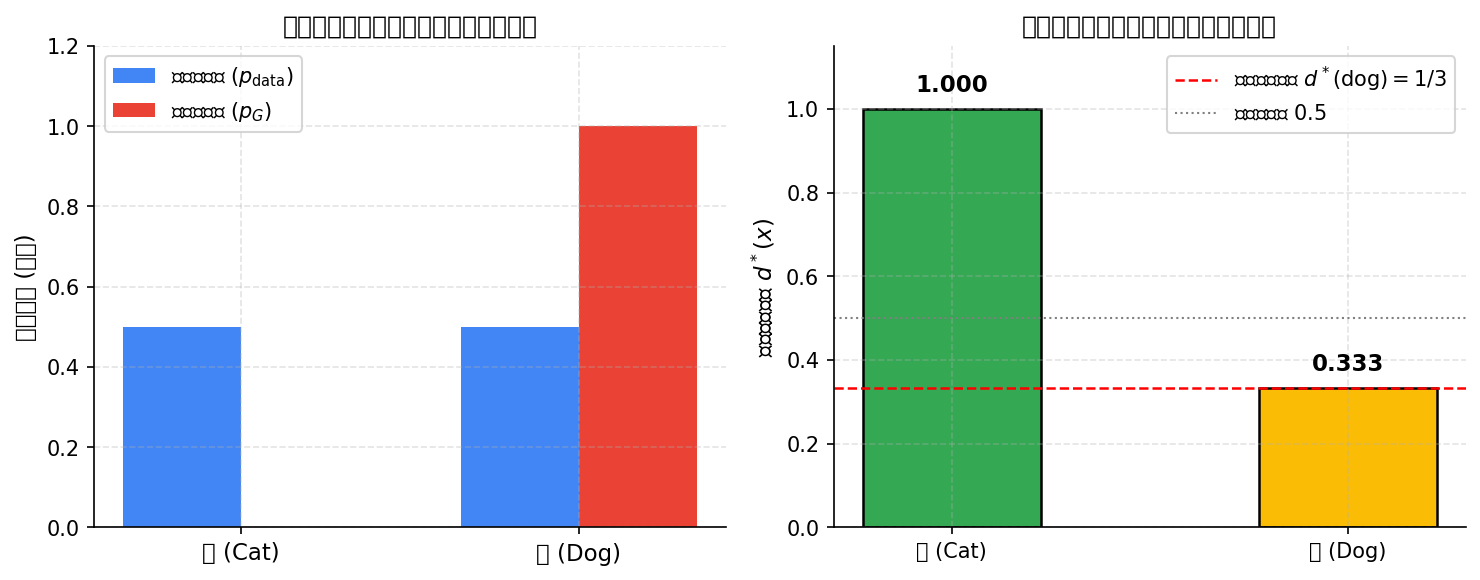

In [11]:
# 演習 17.3 可視化: クラス別確率質量と識別器最適確率
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

# 左図: 識別器に提示される犬・猫サンプルの出所比率
categories = ['猫 (Cat)', '犬 (Dog)']
real_shares = [0.5, 0.5]
synth_shares = [0.0, 1.0]

bar_w = 0.35
x_idx = np.arange(len(categories))

ax1.bar(x_idx - bar_w/2, real_shares, bar_w, label=r'本物データ ($p_{\mathrm{data}}$)', color='#4285F4')
ax1.bar(x_idx + bar_w/2, synth_shares, bar_w, label=r'生成データ ($p_G$)', color='#EA4335')
ax1.set_xticks(x_idx)
ax1.set_xticklabels(categories, fontsize=11)
ax1.set_ylabel('確率質量 (比率)', fontsize=11)
ax1.set_title('各ドメインにおける犬・猫の提示比率', fontsize=12)
ax1.set_ylim(0, 1.2)
ax1.legend(frameon=True)

# 右図: 最適識別器出力 d*(x)
d_outputs = [d_cat, d_dog]
colors = ['#34A853', '#FBBC05']
bars = ax2.bar(categories, d_outputs, width=0.45, color=colors, edgecolor='black', lw=1.2)
ax2.axhline(1.0/3.0, color='red', linestyle='--', lw=1.2, label=r'犬の最適確率 $d^*(\mathrm{dog}) = 1/3$')
ax2.axhline(0.5, color='gray', linestyle=':', lw=1.0, label='均衡時確率 $0.5$')
ax2.set_ylabel(r'最適真贋確率 $d^*(x)$', fontsize=11)
ax2.set_title('提示画像クラスごとの最適識別器出力', fontsize=12)
ax2.set_ylim(0, 1.15)
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.03, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()


---
## 演習のまとめと総括

第17章の演習問題を通じて、GAN の基盤となる3つの本質的な性質を解明しました：
1. **理論的収束保証 (演習 17.1)**:
   無限の表現力を持つモデルでは、大域的定常点において生成分布が真のデータ分布と厳密に一致 ($p_G = p_{\text{data}}$) し、JSD は最小値 $0$ を達成する。
2. **学習の非収束性と力学系的不安定性 (演習 17.2)**:
   ミニマックスゲームの勾配流は保存系 (ハミルトン系) の単振動を引き起こし、鞍点周りの周回軌道にトラップされる。さらに離散時間更新では螺旋発散するため、モメンタム、交互更新、勾配ペナルティ等の正則化機構が不可欠である。
3. **モード崩壊の数理的帰結 (演習 17.3)**:
   生成器が一部のモード (例: 犬のみ) に偏った場合、ベイズの事後確率定理により識別器の均衡出力は偏りを反映した非対称な値 ($1/3$) をとり、未生成モードからの勾配信号が途絶してモード崩壊が固定化される。
